In [1]:
from getdist import plots, MCSamples, loadMCSamples

In [2]:
import os 
import numpy as np

def get_files(path, filename='post_summary.csv', post_names=['dim0', 'dim1', 'dim2']):
    res = [[] for _ in range(len(post_names))]
    for root, dirs, files in os.walk(path):
        for file in files:
            if filename in file:
                for i, name in enumerate(post_names):

                    if name == root.split('/')[-2]:
                        res[i].append(os.path.join(root, file))
    if len(res) == 1:
        res = res[0]
    return res

from typing import Literal, Union
import pandas as pd

def read_post_summary(files: Union[list[str], str], names: list[str], value_esti: Literal['mean', 'median'] = 'median') -> np.ndarray:
    """
    Return the mean or median value and errbounds of the parameters from the post_summary.csv files.
    """
    # check if files is a list
    if isinstance(files, str):
        files = [files]

    # initialize
    measurement = np.zeros((3, len(files), len(names))) # 0: lower, 1: value, 2: upper

    # read post_summary.csv from ultranest
    for i, f in enumerate(files):
        info = pd.read_csv(f)
        for j, name in enumerate(names):
            if value_esti == 'mean':
                measurement[1,i,j] = info[name + '_mean'].item()
                measurement[0,i,j] = measurement[1,i,j] - info[name+'stdev'].item()
                measurement[2,i,j] = measurement[1,i,j] + info[name+'stdev'].item()
            elif value_esti == 'median':
                measurement[1,i,j] = info[name + '_median'].item()
                measurement[0,i,j] = info[name + '_errlo'].item()
                measurement[2,i,j] = info[name + '_errup'].item()
    return measurement

In [3]:
fiducial = np.array([0.3175,0.049,0.6711,0.9624,0.834, 0, -1],dtype=np.float32)
Mnu_pp = np.array([0.3175,0.049,0.6711,0.9624,0.834,0.2,-1],dtype=np.float32)
s8_m = np.array([0.3175,0.049,0.6711,0.9624,0.819,0,-1],dtype=np.float32)
s8_p = np.array([0.3175,0.049,0.6711,0.9624,0.849,0,-1],dtype=np.float32)
Om_m = np.array([0.3075,0.049,0.6711,0.9624,0.834,0,-1],dtype=np.float32)
Om_p = np.array([0.3275,0.049,0.6711,0.9624,0.834,0,-1],dtype=np.float32)

In [4]:
fid_l = np.load('/home/ljy/BettiCurveCosmo/Data/TestData/scale_length/fiducial_ZA_fof.npy')
mpp_l = np.load('/home/ljy/BettiCurveCosmo/Data/TestData/scale_length/Mnu_pp_fof.npy')
s8m_l = np.load('/home/ljy/BettiCurveCosmo/Data/TestData/scale_length/s8_m_fof.npy')
s8p_l = np.load('/home/ljy/BettiCurveCosmo/Data/TestData/scale_length/s8_p_fof.npy')
Omm_l = np.load('/home/ljy/BettiCurveCosmo/Data/TestData/scale_length/Om_m_fof.npy')
Omp_l = np.load('/home/ljy/BettiCurveCosmo/Data/TestData/scale_length/Om_p_fof.npy')
# fid_sub_l = np.load('/home/ljy/BettiCurveCosmo/Data/TestData/scale_length/fiducialZA_sub_fof.npy')
# s8m_sub_l = np.load('/home/ljy/BettiCurveCosmo/Data/TestData/scale_length/s8_m_sub_fof.npy')
# s8p_sub_l = np.load('/home/ljy/BettiCurveCosmo/Data/TestData/scale_length/s8_p_sub_fof.npy')
# Omm_sub_l = np.load('/home/ljy/BettiCurveCosmo/Data/TestData/scale_length/Om_m_sub_fof.npy')
# Omp_sub_l = np.load('/home/ljy/BettiCurveCosmo/Data/TestData/scale_length/Om_p_sub_fof.npy')

In [5]:
fid_marker = np.array(fiducial.tolist()+[np.mean(fid_l)])
mpp_marker = np.array(Mnu_pp.tolist()+[np.mean(mpp_l)])
s8m_marker = np.array(s8_m.tolist()+[np.mean(s8m_l)])
s8p_marker = np.array(s8_p.tolist()+[np.mean(s8p_l)])
Om_m_marker = np.array(Om_m.tolist()+[np.mean(Omm_l)])
Om_p_marker = np.array(Om_p.tolist()+[np.mean(Omp_l)])
# fid_sub_marker = np.array(fiducial.tolist()+[np.mean(fid_sub_l)])
# s8m_sub_marker = np.array(s8_m.tolist()+[np.mean(s8m_sub_l)])
# s8p_sub_marker = np.array(s8_p.tolist()+[np.mean(s8p_sub_l)])
# Om_m_sub_marker = np.array(Om_m.tolist()+[np.mean(Omm_sub_l)])
# Om_p_sub_marker = np.array(Om_p.tolist()+[np.mean(Omp_sub_l)])

In [6]:
# map file index to cosmology
cosmo_map = {'marker':{1:fid_marker, 
             2:mpp_marker, 
             3:s8m_marker, 
             4:s8p_marker, 
             5:Om_m_marker, 
             6:Om_p_marker,
        #      7:fid_sub_marker,
        #      8:s8m_sub_marker,
        #      9:s8p_sub_marker,
        #      10:Om_m_sub_marker,
        #      11:Om_p_sub_marker
             },
             'name':{1:'fid',
                     2:'mpp',
                     3:'s8m',
                     4:'s8p',
                     5:'Omm',
                     6:'Omp',
                #      7:'fid_sub',
                #      8:'s8m_sub',
                #      9:'s8p_sub',
                #      10:'Omm_sub',
                #      11:'Omp_sub'
                }
             }

In [7]:
names = ["Om","Ob","h","ns","s8",'Mnu','w','scale_factor']
labels =  [r"\Omega_m",r"\Omega_b",r"h",r"n_s",r"\sigma_8", r"M_{\nu}", r"w", r'\ell']
priors = [[0.1,0.5], [0.03,0.07], [0.5,0.9], [0.8,1.2], [0.6,1.0], [0,1], [-1.3,-0.7], [0,100]]
ranges = {}
for name, prior in zip(names,priors):
    ranges[name] = prior

In [ ]:
# save prior ranges
np.savetxt('/home/ljy/BettiCurveCosmo/MCMC/weighted_post.ranges', np.concatenate((np.array(names).reshape(-1,1), np.array(priors).astype('str')), axis=1), fmt='%s')

In [8]:
measurement_files = [f'/home/ljy/BettiCurveCosmo/Emulator/model-fof/mcmc_result/nwLH-Recovery/{i}/combined/info/post_summary.csv' for i in range(200)]
measurements = read_post_summary(measurement_files, names)
np.save('/home/ljy/BettiCurveCosmo/Emulator/model-fof/mcmc_result/nwLH-Recovery/measurements.npy', measurements)


In [51]:
# Read measurements for single observation

i = 1 # file index

dim0, dim1, dim2, combined = get_files(f'/home/ljy/BettiCurveCosmo/Emulator/model-fof/mcmc_result/{i}', post_names=['dim0', 'dim1', 'dim2', 'combined'])

measure_all0 =read_post_summary(dim0, names)
measure_all1 =read_post_summary(dim1, names)
measure_all2 =read_post_summary(dim2, names)
measure_allc =read_post_summary(combined, names)

# save measurements
measure_all = np.array([measure_all0, measure_all1, measure_all2, measure_allc])

np.save(f'/home/ljy/BettiCurveCosmo/Emulator/model-fof/mcmc_result/{i}/measurements.npy', measure_all)

In [35]:
i = 3 # file index

combined = get_files(f'/home/ljy/BettiCurveCosmo/Emulator/model-fof-rsdz/mcmc_result/{i}', post_names=['combined'])

measure_allc =read_post_summary(combined, names)

# save measurements
measure_all = np.array(measure_allc)

np.save(f'/home/ljy/BettiCurveCosmo/Emulator/model-fof-rsdz/mcmc_result/{i}/measurements.npy', measure_all)


In [52]:
# Calculate improvement

BCs = read_post_summary(get_files(f'/home/ljy/BettiCurveCosmo/Emulator/model-fof/mcmc_result/1',post_names=['combined']), names)
powspec = read_post_summary(get_files(f'/home/ljy/BettiCurveCosmo/PowSpec/model/model-fof/mcmc_result/1',post_names=['dim0']), names)
BCs_rsdz = read_post_summary(get_files(f'/home/ljy/BettiCurveCosmo/Emulator/model-fof-rsdz/mcmc_result/1',post_names=['combined']), names)
powspec_rsdz = read_post_summary(get_files(f'/home/ljy/BettiCurveCosmo/PowSpec/model/model-fof-rsdz/mcmc_result/1',post_names=['combined']), names)
combined = read_post_summary(get_files(f'/home/ljy/BettiCurveCosmo/MCMC/BC_Pk/result',post_names=['fza-fof']), names)
combined_rsdz = read_post_summary(get_files(f'/home/ljy/BettiCurveCosmo/MCMC/BC_Pk/result',post_names=['fza-fof-rsdz']), names)

In [9]:
BCs_err = BCs[2] - BCs[0]
powspec_err = powspec[2] - powspec[0]
BCs_rsdz_err = BCs_rsdz[2] - BCs_rsdz[0]
powspec_rsdz_err = powspec_rsdz[2] - powspec_rsdz[0]
combined_err = combined[2] - combined[0]
combined_rsdz_err = combined_rsdz[2] - combined_rsdz[0]

import matplotlib.pyplot as plt
x = np.arange(len(names))
plt.figure(figsize=(10, 6))
plt.plot(x, BCs_err[0], label='BC012')
plt.plot(x, powspec_err[0], label='Pk0')
plt.plot(x, combined_err[0], label='BC012+Pk0')
plt.legend()
plt.xticks(x, labels)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(x, BCs_rsdz_err[0], label='BC012')
plt.plot(x, powspec_rsdz_err[0], label='Pk02')
plt.plot(x, combined_rsdz_err[0], label='BC012+Pk02')
plt.legend()
plt.xticks(x, labels)
plt.show()

In [64]:
print(BCs_err/powspec_err-1)
print(BCs_rsdz_err/powspec_rsdz_err-1)
print(combined_err/powspec_err-1)
print((combined_rsdz_err/powspec_rsdz_err-1))
print(combined_rsdz_err/combined_err-1)
# print(powspec_rsdz_err/powspec_err-1)
print(BCs_rsdz_err/BCs_err-1)

[[ 0.14828525  0.04233184  0.13442643 -0.45675498 -0.63340446 -0.05573452
   0.00561316 -0.53281981]]
[[-0.04679153  0.08721613  0.03026875 -0.43454725 -0.59858992  0.05049592
  -0.01934681 -0.28212191]]
[[-0.19022886 -0.06759555  0.02722301 -0.49966798 -0.68535009 -0.05794734
  -0.08090575 -0.72087446]]
[[-0.21668706 -0.04539258 -0.03061438 -0.42744649 -0.67212872 -0.03227889
  -0.18365115 -0.69304389]]
[[-0.05922562  0.01767803  0.03636072 -0.00392165 -0.30706673 -0.12296595
  -0.18327644  0.064993  ]]
[[-0.19267095  0.03681151 -0.00263689 -0.09398315 -0.27185689 -0.0501792
  -0.10330686  0.48811445]]


In [55]:
BCs_err/2/BCs[1]*100


array([[ 15.66432334,  24.25657613,  17.63868644,   6.57502427,
          2.87202594,  67.81457211, -19.89827282,   0.70013374]])

In [61]:
%%bash -s "$i" # create soft link to range and param file
i=1
for d in /home/ljy/BettiCurveCosmo/Emulator/model-fof/mcmc_result/${i}/dim?/chains; do ln -sf /home/ljy/BettiCurveCosmo/MCMC/weighted_post.ranges $d/weighted_post.ranges; done
for d in /home/ljy/BettiCurveCosmo/Emulator/model-fof/mcmc_result/${i}/dim?/chains; do ln -sf /home/ljy/BettiCurveCosmo/MCMC/weighted_post.paramnames $d/weighted_post.paramnames; done
ln -sf /home/ljy/BettiCurveCosmo/MCMC/weighted_post.ranges /home/ljy/BettiCurveCosmo/Emulator/model-fof/mcmc_result/${i}/combined/chains/weighted_post.ranges
ln -sf /home/ljy/BettiCurveCosmo/MCMC/weighted_post.paramnames /home/ljy/BettiCurveCosmo/Emulator/model-fof/mcmc_result/${i}/combined/chains/weighted_post.paramnames

In [8]:
%%bash -s "$i" # create soft link to range and param file
i=5
ln -sf /home/ljy/BettiCurveCosmo/MCMC/weighted_post.ranges /home/ljy/BettiCurveCosmo/Emulator/model-fof/mcmc_result/${i}/combined/chains/weighted_post.ranges
ln -sf /home/ljy/BettiCurveCosmo/MCMC/weighted_post.paramnames /home/ljy/BettiCurveCosmo/Emulator/model-fof/mcmc_result/${i}/combined/chains/weighted_post.paramnames

In [69]:
!ln -sf /home/ljy/BettiCurveCosmo/MCMC/weighted_post.ranges /home/ljy/BettiCurveCosmo/MCMC/BC_Pk/result/fza-fof/chains/weighted_post.ranges
!ln -sf /home/ljy/BettiCurveCosmo/MCMC/weighted_post.paramnames /home/ljy/BettiCurveCosmo/MCMC/BC_Pk/result/fza-fof/chains/weighted_post.paramnames


In [31]:
!ln -sf /home/ljy/BettiCurveCosmo/MCMC/weighted_post.ranges /home/ljy/BettiCurveCosmo/PowSpec/model/model-fof/mcmc_result/1/dim0/chains/weighted_post.ranges
!ln -sf /home/ljy/BettiCurveCosmo/MCMC/weighted_post.paramnames /home/ljy/BettiCurveCosmo/PowSpec/model/model-fof/mcmc_result/1/dim0/chains/weighted_post.paramnames

In [ ]:
latex = []
for i in range(1,12): 
    m = np.load(f'/home/ljy/BettiCurveCosmo/Emulator/model-fof/mcmc_result/{i}/measurements.npy')
    for i in range(4):
        lower = (m[i,1,:]-m[i,0,:]).squeeze()
        upper = (m[i,2,:]-m[i,1,:]).squeeze()
        mid = m[i,1,:].squeeze()
        latex.append([f"${mid[j]:.4f}^"+"{+"+f"{upper[j]:.4f}"+"}_{-"+f"{lower[j]:.4f}"+"}$" for j in range(8)])
print(latex)

In [27]:
import pandas as pd
csv = pd.DataFrame(latex, columns=labels)
csv.to_csv('/home/ljy/project/emulator/GPR/model/exp2/search14/mcmc_result/measurements.csv', index=False)

In [62]:
# BC0 = np.loadtxt(f'/home/ljy/project/emulator/GPR/model/exp2/search14/mcmc_result/{i}/dim0/chains/weighted_post.txt', skiprows=1)
# BC1 = np.loadtxt(f'/home/ljy/project/emulator/GPR/model/exp2/search14/mcmc_result/{i}/dim1/chains/weighted_post.txt', skiprows=1)
# BC2 = np.loadtxt(f'/home/ljy/project/emulator/GPR/model/exp2/search14/mcmc_result/{i}/dim2/chains/weighted_post.txt', skiprows=1)
# BCs = np.loadtxt(f'/home/ljy/project/emulator/GPR/model/exp2/search14/mcmc_result/{i}/combined/chains/weighted_post.txt', skiprows=1)

# 1 for full box 2 for sub box
# no rsdz dim0 for new result
samples_BC2 = loadMCSamples(f'/home/ljy/BettiCurveCosmo/Emulator/model-fof/mcmc_result/1/dim2/chains/weighted_post',settings={'ignore_rows':1})
samples_BC1 = loadMCSamples(f'/home/ljy/BettiCurveCosmo/Emulator/model-fof/mcmc_result/1/dim1/chains/weighted_post',settings={'ignore_rows':1})
samples_BC0 = loadMCSamples(f'/home/ljy/BettiCurveCosmo/Emulator/model-fof/mcmc_result/1/dim0/chains/weighted_post',settings={'ignore_rows':1})
samples_BCs = loadMCSamples(f'/home/ljy/BettiCurveCosmo/Emulator/model-fof/mcmc_result/1/combined/chains/weighted_post',settings={'ignore_rows':1})

g = plots.get_subplot_plotter()
plot_args = [
    {'filled': True, 'alpha': 0.5, }, 
    {'filled': True, 'alpha': 0.5, }, 
    {'filled': True, 'alpha': 0.5, }, 
    {'filled': True, 'alpha': 1, },
]

g.settings.alpha_filled_add = 0.5
g.settings.linewidth = 1.5
# g.settings.line_styles = 'tab10'
g.settings.alpha_factor_contour_lines = 0.5
g.settings.legend_fontsize = 20       # 图例字体大小
g.settings.lab_fontsize = 16           # 坐标轴标签字体大小

g.settings.figure_legend_frame = 0
g.triangle_plot([samples_BC0, samples_BC1, samples_BC2, samples_BCs], 
                legend_labels=[r'$\hat\beta_0$', r'$\hat\beta_1$', r'$\hat\beta_2$', r'$\hat\beta_{0,1,2}$'],
                params=["Om","Ob","h","ns","s8",'Mnu','w'],
                markers=cosmo_map['marker'][1][:-1],
                legend_loc='upper right', 
                contour_args=plot_args,
                contour_colors=['tab:red', 'tab:orange', 'tab:green', 'tab:blue'],
                # shaded=True,
                )

# sim = cosmo_map['name'][i]
g.export(f'/home/ljy/BettiCurveCosmo/Fig/BCs_fza.pdf')


/home/ljy/BettiCurveCosmo/Emulator/model-fof/mcmc_result/1/dim0/chains/weighted_post.txt
/home/ljy/BettiCurveCosmo/Emulator/model-fof/mcmc_result/1/combined/chains/weighted_post.txt


In [71]:
# comapre w/ or w/o RSD

samples = loadMCSamples(f'/home/ljy/BettiCurveCosmo/Emulator/model-fof/mcmc_result/1/combined/chains/weighted_post',settings={'ignore_rows':1})
samples_rsdz = loadMCSamples(f'/home/ljy/BettiCurveCosmo/Emulator/model-fof-rsdz/mcmc_result/1/combined/chains/weighted_post',settings={'ignore_rows':1})

g = plots.get_subplot_plotter()
# g.settings.alpha_filled_add = 0.5
g.settings.linewidth = 1.5
g.settings.line_styles = 'tab10'
g.settings.alpha_factor_contour_lines = 0.5
g.settings.figure_legend_frame = 0
g.settings.legend_fontsize = 20       # 图例字体大小
g.settings.lab_fontsize = 16           # 坐标轴标签字体大小
g.triangle_plot([samples_rsdz, samples,], 
                # params=['Om', 's8'], 
                legend_labels=['w/ RSD', 'w/o RSD', ],   
                markers=cosmo_map['marker'][1][:-1],
                params=["Om","Ob","h","ns","s8",'Mnu','w'],
                legend_loc='upper right', 
                filled=True,
                # shaded=True,
                # line_args=[{'lw':1.5}]

                )


g.export(f'/home/ljy/BettiCurveCosmo/Fig/BCs_fza_compare-rsd.pdf')


In [ ]:
# comapre fza result using cov s8m / s8p

rsd = False
if rsd:
    samples_covs8m = loadMCSamples(f'/home/ljy/BettiCurveCosmo/Emulator/model-fof-rsdz/mcmc_result/3/combined/chains/weighted_post',settings={'ignore_rows':1})
    samples_covs8p = loadMCSamples(f'/home/ljy/BettiCurveCosmo/Emulator/model-fof-rsdz/mcmc_result/4/combined/chains/weighted_post',settings={'ignore_rows':1})
    samples_covfid = loadMCSamples(f'/home/ljy/BettiCurveCosmo/Emulator/model-fof-rsdz/mcmc_result/1/combined/chains/weighted_post',settings={'ignore_rows':1})
else:
    samples_covs8m = loadMCSamples(f'/home/ljy/BettiCurveCosmo/Emulator/model-fof/mcmc_result/3/combined/chains/weighted_post',settings={'ignore_rows':1})
    samples_covs8p = loadMCSamples(f'/home/ljy/BettiCurveCosmo/Emulator/model-fof/mcmc_result/4/combined/chains/weighted_post',settings={'ignore_rows':1})
    samples_covfid = loadMCSamples(f'/home/ljy/BettiCurveCosmo/Emulator/model-fof/mcmc_result/1/combined/chains/weighted_post',settings={'ignore_rows':1})

g = plots.get_subplot_plotter()
# g.settings.alpha_filled_add = 0.5
g.settings.linewidth = 1.5
g.settings.line_styles = 'tab10'
g.settings.alpha_factor_contour_lines = 0.5
g.settings.figure_legend_frame = 0
g.settings.legend_fontsize = 20       # 图例字体大小
g.settings.lab_fontsize = 16           # 坐标轴标签字体大小
g.triangle_plot([samples_covfid, samples_covs8m, samples_covs8p,], 
                # params=['Om', 's8'], 
                legend_labels=[r'$\mathrm{Cov}(\text{fid})$', r'$\mathrm{Cov}(\sigma_8^-)$', r'$\mathrm{Cov}(\sigma_8^+)$'],   
                markers=cosmo_map['marker'][1][:-1],
                params=["Om","Ob","h","ns","s8",'Mnu','w'],
                legend_loc='upper right', 
                filled=True,
                # shaded=True,
                # line_args=[{'lw':1.5}]

                )


g.export(f'/home/ljy/BettiCurveCosmo/Fig/BCs_fza_compare-cov.pdf')

In [70]:
rsd = False
samples_BCs = loadMCSamples(f'/home/ljy/BettiCurveCosmo/Emulator/model-fof-rsdz/mcmc_result/1/combined/chains/weighted_post',settings={'ignore_rows':1}) if rsd else loadMCSamples(f'/home/ljy/BettiCurveCosmo/Emulator/model-fof/mcmc_result/1/combined/chains/weighted_post',settings={'ignore_rows':1})
samples_powspec = loadMCSamples(f'/home/ljy/BettiCurveCosmo/PowSpec/model/model-fof-rsdz/mcmc_result/1/combined/chains/weighted_post',settings={'ignore_rows':1}) if rsd else loadMCSamples(f'/home/ljy/BettiCurveCosmo/PowSpec/model/model-fof/mcmc_result/1/dim0/chains/weighted_post',settings={'ignore_rows':1})
samples_combined= loadMCSamples(f'/home/ljy/BettiCurveCosmo/MCMC/BC_Pk/result/fza-fof-rsdz/chains/weighted_post',settings={'ignore_rows':1}) if rsd else loadMCSamples(f'/home/ljy/BettiCurveCosmo/MCMC/BC_Pk/result/fza-fof/chains/weighted_post',settings={'ignore_rows':1})
samples_combined_rsdz= loadMCSamples(f'/home/ljy/BettiCurveCosmo/MCMC/BC_Pk/result/fza-fof-rsdz/chains/weighted_post',settings={'ignore_rows':1})

contour_args = [
    {'filled': True, 'alpha': 0.5, }, 
    {'filled': True, 'alpha': 0.5, }, 
    {'filled': True, 'alpha': 1, }, 
]

g = plots.get_subplot_plotter()
# g.settings.alpha_filled_add = 0.5
g.settings.linewidth = 1.5
g.settings.line_styles = 'tab10'
g.settings.alpha_factor_contour_lines = 0.5
g.settings.figure_legend_frame = 0
g.settings.legend_fontsize = 20       # 图例字体大小
g.settings.lab_fontsize = 16           # 坐标轴标签字体大小
g.triangle_plot(
    [samples_BCs, samples_powspec,samples_combined, ],
                # [samples_combined_rsdz, samples_combined], 
                # params=['Om', 's8'], 
                # params=["Om","Ob","h","ns","s8"],
                params=["Om","Ob","h","ns","s8",'Mnu','w'],
                legend_labels=[r'$\hat\beta_{0,1,2}$', r'$P_{0,2}(k)$', r'$\hat\beta_{0,1,2}+P_{0,2}(k)$'] if rsd else [r'$\hat\beta_{0,1,2}$', r'$P_{0}(k)$', r'$\hat\beta_{0,1,2}+P_{0}(k)$'],
                # legend_labels=['BC+Pk w/ rsdz', 'BC+Pk w/o rsdz', ],
                markers=cosmo_map['marker'][1][:-1],#[0:5],#[[0,4]],
                legend_loc='upper right', 
                # title_limit=1, 
                filled=True,
                contour_args=contour_args,
                # shaded=True,
                # line_args=[{'lw':1.5}]
                )

sim = cosmo_map['name'][1]
g.export(f'/home/ljy/BettiCurveCosmo/Fig/BC-Pk_{sim}{"_rsd" if rsd else ""}.pdf')
# g.export(f'/home/ljy/BettiCurveCosmo/Fig/BC-Pk_{sim}_compare-rsd.pdf')
# g.export(f'/home/ljy/BettiCurveCosmo/Fig/BCs-Pk_{sim}_rsdz_standard.png')


/home/ljy/BettiCurveCosmo/MCMC/BC_Pk/result/fza-fof/chains/weighted_post.txt


# nwLH Validation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import MCSamples
import sys
sys.path.append('..')
import Emulator.GPRemulator as gpr 
from Emulator.GPRemulator import custom_optimizer, PCAForY
import os

In [ ]:
rsd = True
mean_measure = np.load('/home/ljy/BettiCurveCosmo/Emulator/model-fof-rsdz/mcmc_result/nwLH-Recovery/measurements.npy') if rsd else np.load('/home/ljy/BettiCurveCosmo/Emulator/model-fof/mcmc_result/nwLH-Recovery/measurements.npy')

mean_value = mean_measure[1, :, :].squeeze()
mean_errlo = mean_value - mean_measure[0, :, :].squeeze()
mean_errup = mean_measure[2, :, :].squeeze() - mean_value

truth = np.load('/home/ljy/BettiCurveCosmo/Emulator/model-fof-rsdz/mcmc_result/nwLH-Recovery/truth.npy') if rsd else np.load('/home/ljy/BettiCurveCosmo/Emulator/model-fof/mcmc_result/nwLH-Recovery/truth.npy')

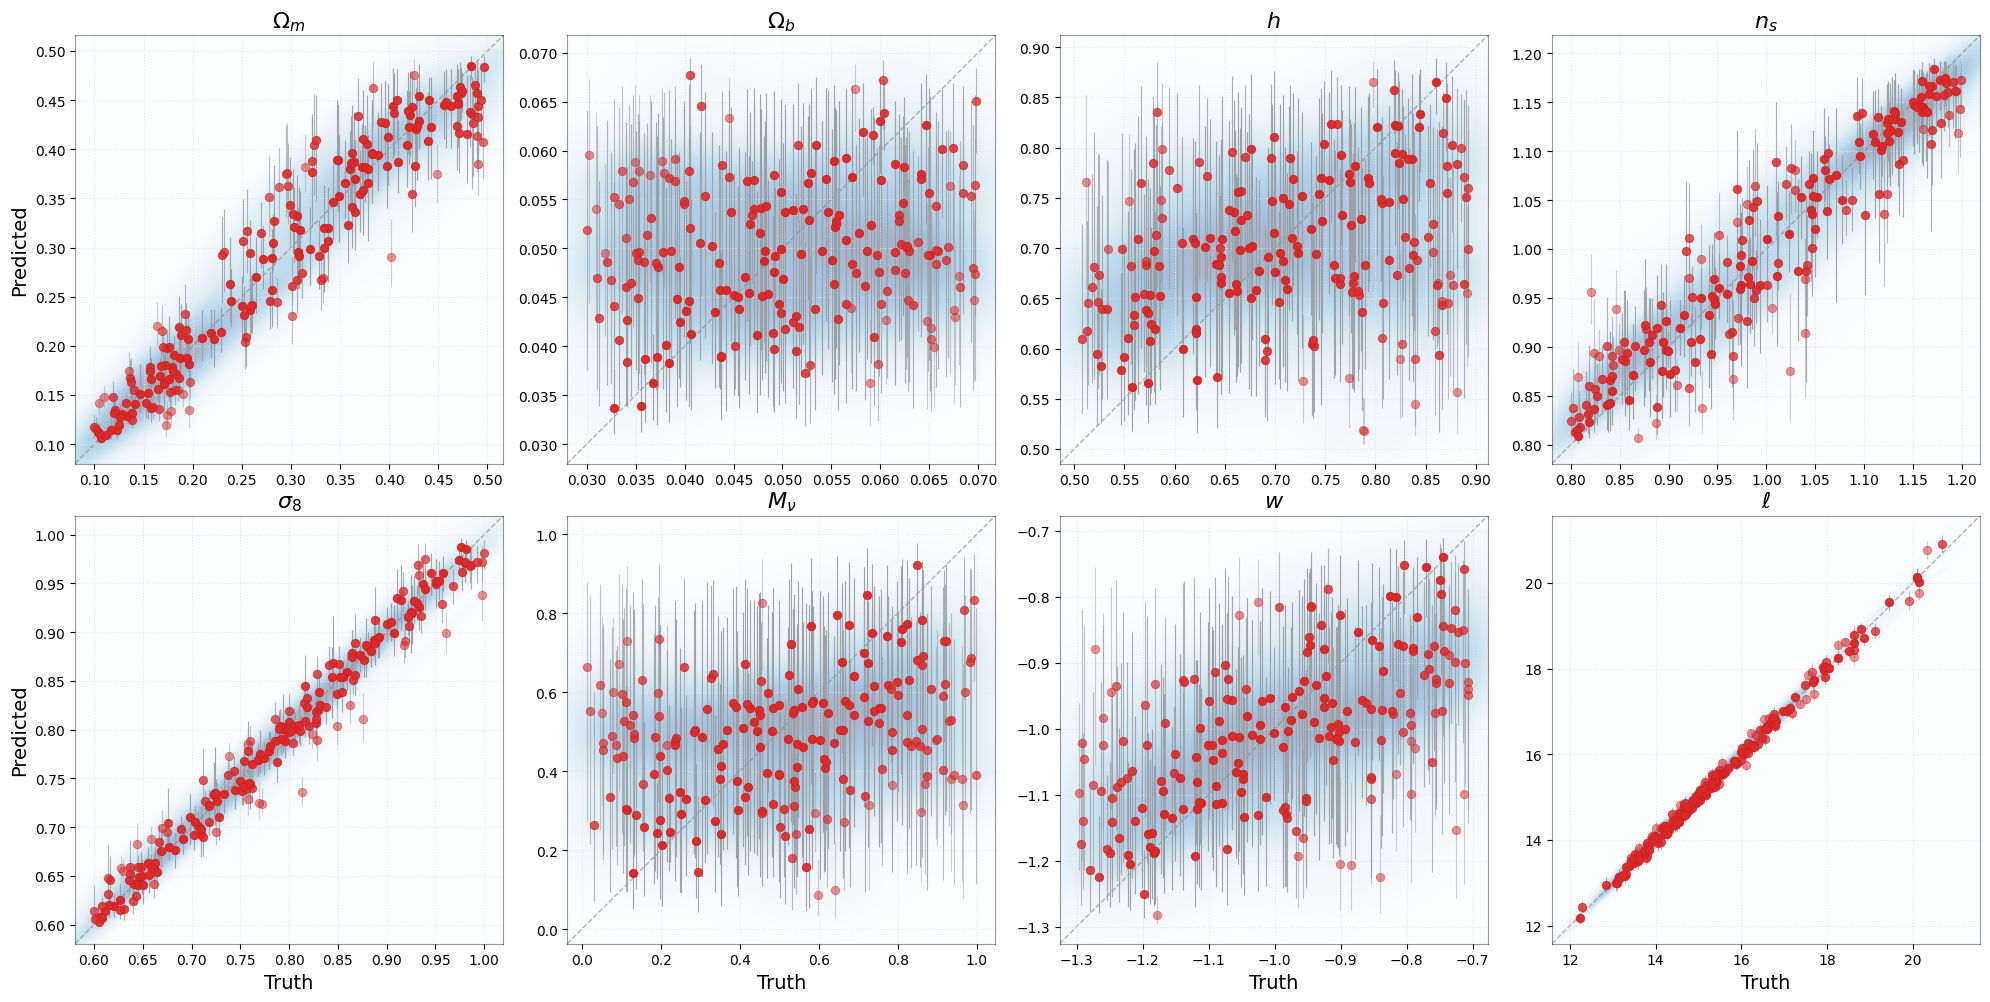

In [ ]:

from sklearn.metrics import r2_score
from scipy.stats import gaussian_kde  
fiducial = np.array([0.3175,0.049,0.6711,0.9624,0.834, 0, -1],dtype=np.float32)

fid_l = np.load('/home/ljy/BettiCurveCosmo/Data/TestData/scale_length/fiducial_ZA_fof.npy')
fid_marker = np.array(fiducial.tolist()+[np.mean(fid_l)])
labels = [r"$\Omega_m$",r"$\Omega_b$",r"$h$",r"$n_s$",r"$\sigma_8$", r"$M_{\nu}$", r"$w$", r"$\ell$"]
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

base_color = "#d62b2b"
edge_color = "#db1a1a"
err_color  = "#9aa0a6"

for i in range(len(labels)):
    ax = axes[i//4, i%4]
    r2 = r2_score(truth[:, i], mean_value[:, i])

    residuals = truth[:, i] - mean_value[:, i]
    sigma = np.where(residuals > 0, mean_errup[:, i], mean_errlo[:, i])

    # 残差标准差（可用于其他统计注释）
    std_res = float(np.nanstd(residuals))
    if (not np.isfinite(std_res)) or (std_res == 0):
        std_res = 1.0

    # chi2 -> alpha（越大越透明）
    with np.errstate(divide='ignore', invalid='ignore'):
        chi2_i = (residuals / sigma)**2
    cap = np.nanpercentile(chi2_i, 95) if np.isfinite(np.nanmax(chi2_i)) else 1.0
    cap = cap if cap > 0 else 1.0
    alphas = 1.0 - 0.5 * np.clip(chi2_i / cap, 0, 1)
    alphas = np.where(np.isfinite(alphas), alphas, 0.5)

    npts = truth.shape[0]

    # 逐点绘制（alpha 随 chi2）
    for j in range(npts):
        ax.errorbar(
            truth[j, i],
            mean_value[j, i],
            yerr=[[mean_errlo[j, i]], [mean_errup[j, i]]],
            fmt='o',
            color=base_color,
            markerfacecolor=base_color,
            markeredgecolor=edge_color,
            mew=0.6,
            ecolor=err_color,
            elinewidth=0.8,
            markersize=6,
            alpha=float(alphas[j]),
            zorder=3
        )

    # 统一轴范围，确保 45° 参考线正确
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    vmin = min(xlim[0], ylim[0])
    vmax = max(xlim[1], ylim[1])
    ax.set_xlim(vmin, vmax)
    ax.set_ylim(vmin, vmax)

    # 背景密度填充：2D KDE on (Truth, Predicted)
    data = np.vstack([truth[:, i].astype(float), mean_value[:, i].astype(float)])
    msk = np.isfinite(data).all(axis=0)
    data = data[:, msk]
    if data.shape[1] >= 3 and np.ptp(data[0]) > 0 and np.ptp(data[1]) > 0:
        try:
            kde = gaussian_kde(data, bw_method='scott')
        except np.linalg.LinAlgError:
            # 共线或奇异，加入极小抖动后再估计
            jitter = 1e-4 * (vmax - vmin)
            kde = gaussian_kde(data + np.random.normal(scale=jitter, size=data.shape), bw_method='scott')

        gx = np.linspace(vmin, vmax, 200)
        gy = np.linspace(vmin, vmax, 200)
        GX, GY = np.meshgrid(gx, gy)
        Z = kde(np.vstack([GX.ravel(), GY.ravel()])).reshape(GX.shape)
        Z = np.nan_to_num(Z, nan=0.0, posinf=0.0, neginf=0.0)
        zmax = np.percentile(Z, 99)
        zmax = zmax if zmax > 0 else (Z.max() if Z.max() > 0 else 1.0)

        ax.imshow(
            Z, extent=[vmin, vmax, vmin, vmax], origin='lower',
            cmap='Blues', vmin=0, vmax=zmax, alpha=0.35,
            interpolation='bilinear', zorder=0
        )

    if i == 0 or i == 4:
        ax.set_ylabel(r'Predicted', fontsize=14)
    if i > 3:
        ax.set_xlabel(r'Truth', fontsize=14)
    ax.set_title(labels[i], fontsize=16)

    # 对角线
    ax.plot([vmin, vmax], [vmin, vmax], ls='--', color='0.5', lw=1, alpha=0.6, zorder=1)

    # 美化
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, ls=':', color='0.9')
    for sp in ax.spines.values():
        sp.set_alpha(0.4)

plt.tight_layout()
plt.savefig('../Fig/nwLH_recovery_fof_rsdz.pdf', dpi=300)
